1.Importing Libraries

In [148]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [149]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [150]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [151]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [152]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

2.Load  Dataset

In [155]:
iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

3.Exploratory Data Analysis (EDA)

In [157]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [158]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [159]:
df.head(4)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa


In [160]:
df.tail(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [161]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

In [162]:
df.shape

(150, 5)

In [163]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [164]:
df.isnull().sum().sum()

0

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [166]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

In [167]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [168]:
df.value_counts()

sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  species   
5.8                2.7               5.1                1.9               virginica     2
6.2                2.2               4.5                1.5               versicolor    1
                   2.9               4.3                1.3               versicolor    1
                   3.4               5.4                2.3               virginica     1
6.3                2.3               4.4                1.3               versicolor    1
                                                                                       ..
5.4                3.9               1.3                0.4               setosa        1
                                     1.7                0.4               setosa        1
5.5                2.3               4.0                1.3               versicolor    1
                   2.4               3.7                1.0               versicolor    1
7.9            

In [170]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

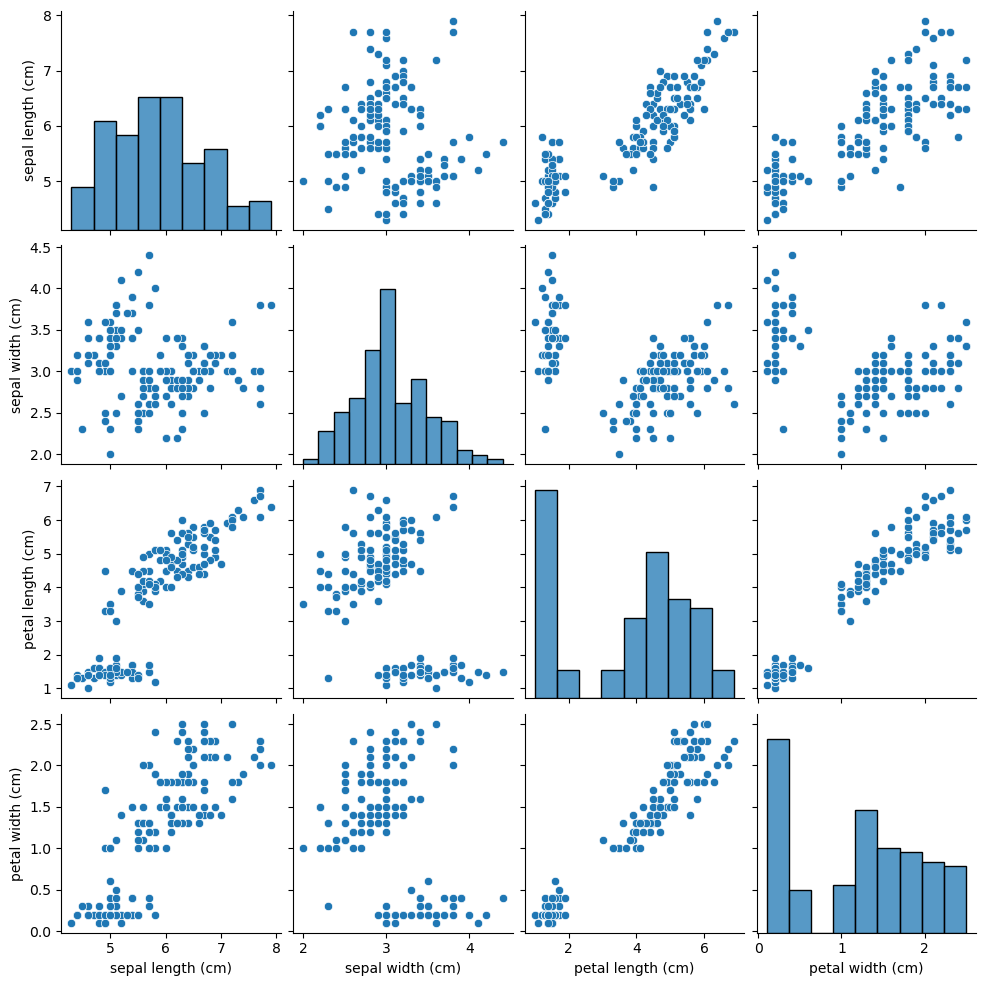

In [171]:
sns.pairplot(df)

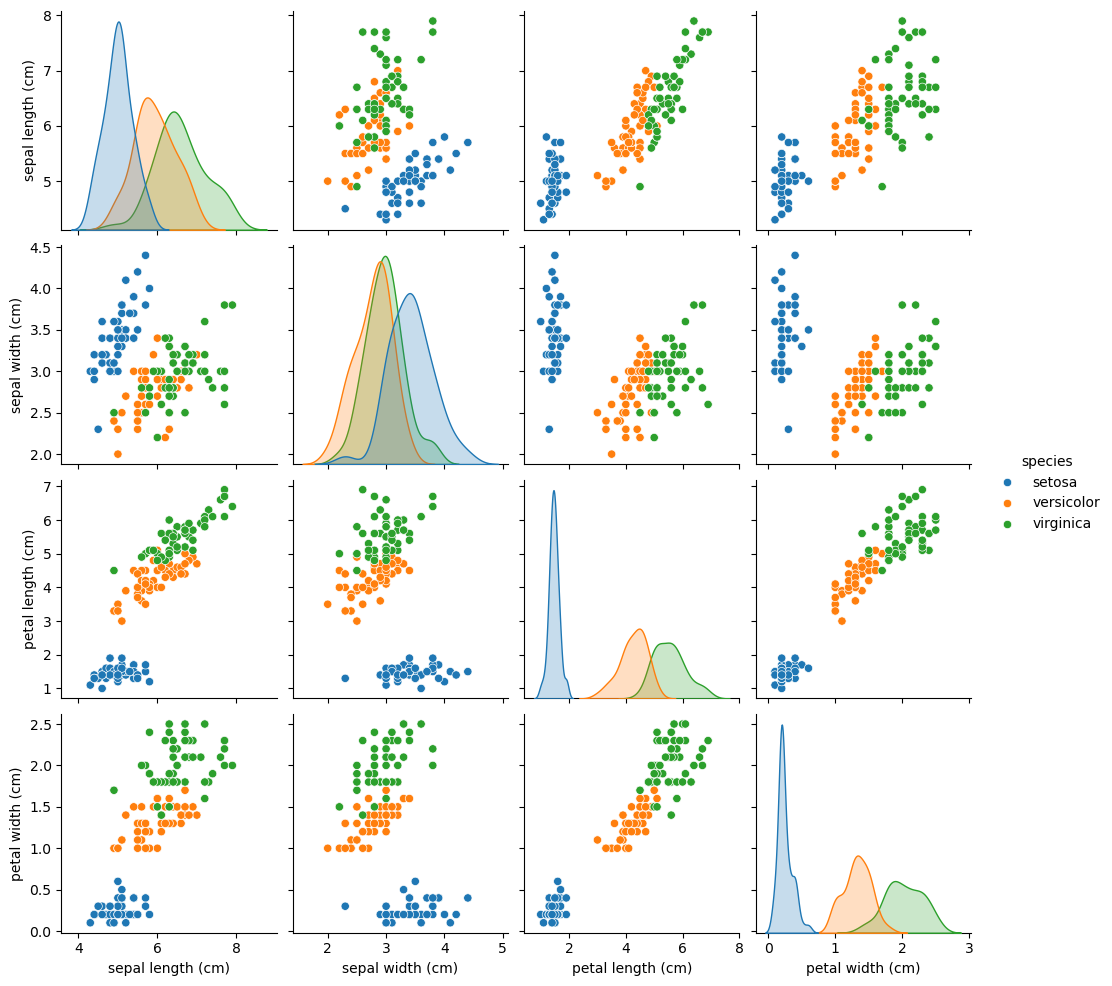

In [172]:
sns.pairplot(df,hue="species")

<Axes: ylabel='Count'>

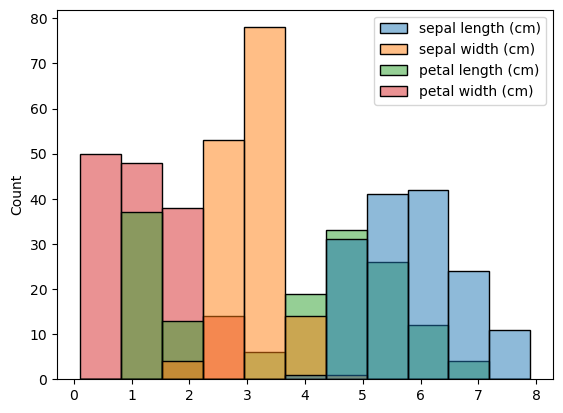

In [173]:
sns.histplot(df)

4. Split Features & Target

In [175]:
X = df.drop('species', axis=1)
y = df['species']

5.Splilt dataset into training  part and testing part

In [178]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,) #random_state=42)

6.Train SVM model

In [181]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

7.predictions

In [184]:
y_pred=model.predict(X_test)
y_pred

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'versicolor', 'setosa', 'setosa', 'setosa',
       'virginica', 'versicolor', 'virginica', 'setosa', 'virginica',
       'versicolor', 'virginica', 'versicolor', 'virginica', 'virginica',
       'setosa', 'setosa', 'virginica', 'versicolor', 'virginica',
       'virginica', 'versicolor', 'versicolor', 'versicolor'],
      dtype=object)

8.Model Evaluation

In [193]:
print(accuracy_score(y_test, y_pred))

1.0


print(classification_report(y_test, y_pred))

9.Confusion Matrix

In [231]:
from sklearn.metrics import confusion_matrix

In [233]:
confusion_matrix(y_pred,y_test)

array([[ 8,  0,  0],
       [ 0, 11,  0],
       [ 0,  0, 11]], dtype=int64)

<Axes: >

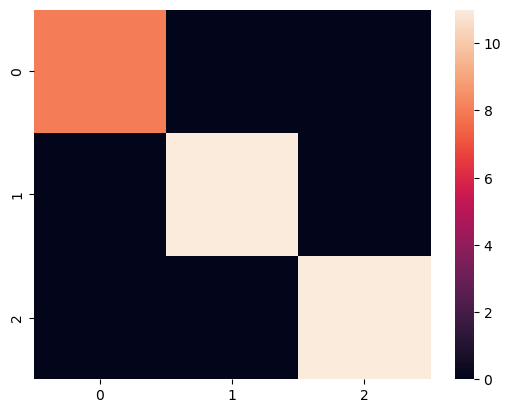

In [235]:
sns.heatmap(confusion_matrix(y_pred,y_test))